In [124]:
import pandas, os
import matplotlib.pyplot as plt
import numpy as np
from rich import print

plt.rcParams['font.size'] = 15

<========================================================================================================================>
                                             Teste de Regressão Multilinear                                             
<========================================================================================================================>


>> AX = b ; X = Vh.T S^-1 U* b

VT shape: (14, 14)
S shape: (14, 14)
U shape: (506, 14)
A shape: (506, 14)
b shape: (506,)

X shape: (14,)

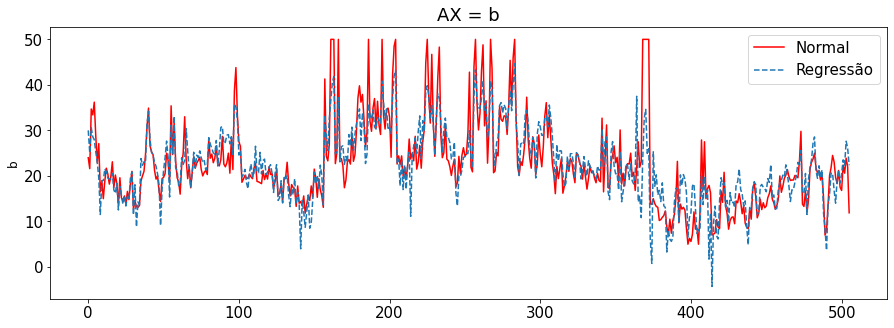

In [125]:


data = np.loadtxt(os.path.join('datasets/housing.csv'))

b = data[:,-1]
A = data[:,:-1]

# Pad with ones for nonzero offsets
A = np.pad(A,[(0,0),(0,1)], mode='constant', constant_values=1)


# REGRESSÃO...

U,S,VT = np.linalg.svd(A, full_matrices=0)
S = np.diag(S)

print(f""" >> AX = b ; X = Vh.T S^-1 U* b

VT shape: {VT.shape}
S shape: {S.shape}
U shape: {U.shape}
A shape: {A.shape}
b shape: {b.shape}
""")
            
X = VT.T @ np.linalg.inv(S) @ U.T @ b 
print(f'X shape: {X.shape}')

plt.figure('plot_normal', figsize=(15,5))
plt.title(f'AX = b')
plt.ylabel('b')
plt.rc('axes', labelsize=12)
plt.plot(b, color='red', label='Normal') # Plot normal
plt.plot(A @ X, '--', label='Regressão') # Plot da regressão
plt.legend()
plt.show()